# 쇼핑몰 데이터 분석 - 문제·팀원 답안 취합

사용 파일: `shopping_sales.csv`

원본의 **65문제**를 번호순으로 정리하고 각 문제 바로 아래에 제출된 답안을 배치했습니다. **1~59번은 팀원 제출 답안이며, 60~65번은 원본 CSV로 계산한 추가 풀이**입니다.

| 원본 단원 | 담당 답안 | 작성자 |
|---|---|---|
| 1·3·8단원 | 1~5, 11~13, 37~40 | 박주형 |
| 2·7단원 | 6~10, 26~36 | 이준원 |
| 4·9단원 | 14~18, 41~46 | 이재현 |
| 5·10단원 | 19~21, 47~54 | 윤지석 |
| 6·11단원 | 22~25, 55~59 | 강은영 |
| 12단원 | 60~65 | 추가 풀이 |

> 1~59번 코드와 저장된 출력은 팀원의 제출본을 보존한 내용이며 새로 실행한 결과가 아닙니다. 60~65번의 추가 풀이와 출력은 제공된 원본 CSV를 기준으로 실제 실행했습니다. 한 셀에 여러 문제가 있던 답안은 번호별로 나눴고, 중복 풀이와 개별 파일의 준비 코드는 마지막 참고 부분에 모았습니다. 재배치한 셀의 실행 번호는 초기화했으며 원본 파일·셀 위치·실행 번호는 메타데이터에 기록했습니다.

**재실행 전 확인:** 18번의 미정의 변수, 원본 파일별 데이터 전처리 차이, 47번 이후 날짜 인덱스 변경과 57~59번의 `order_date` 컬럼 참조를 확인하세요. 자세한 취합 메모는 마지막에 있습니다.

## 공통 라이브러리 준비

팀원이 제출한 라이브러리 준비 코드를 앞에 배치했습니다.

In [ ]:
import pandas as pd

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import matplotlib
matplotlib.rcParams['font.family']='Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False


## 1. 데이터 불러오기 및 확인

### 1. `shopping_sales.csv` 파일을 불러와 데이터프레임으로 저장하시오.

**답안 작성: 박주형**

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/joyi-dev-kr/260930/main/shopping_sales.csv')
df

,order_id,order_date,customer_id,gender,age,region,category,product,quantity,price,discount,payment
0,ORD002588,2025-05-30 03:04:29,C00281,여,33.0,인천,식품,생수24개,1,11100,0.15,간편결제
1,ORD000526,2025-12-01 06:15:22,C00333,남,30.0,부산,생활용품,수납함,5,26400,0.00,체크카드
2,ORD001244,2025-11-09 10:57:44,C00786,남,19.0,부산,뷰티,수분크림,2,31300,0.10,NaN
3,ORD002049,2026-01-18 17:59:52,C01015,여,44.0,경기,패션,청바지,1,67000,0.15,계좌이체
4,ORD000730,2025-07-15 07:43:08,C00397,여,43.0,울산,생활용품,전기포트,2,49900,0.00,계좌이체
...,...,...,...,...,...,...,...,...,...,...,...,...
5075,ORD002341,2025-11-26 03:33:33,C01153,NaN,32.0,대전,패션,백팩,1,74600,0.05,계좌이체
5076,ORD003467,2025-07-12 08:34:35,C01228,여,38.0,경남,전자기기,스마트워치,1,153200,0.00,계좌이체
5077,ORD004566,2025-01-22 12:16:30,C01123,여,53.0,광주,전자기기,스마트워치,1,146800,0.10,신용카드
5078,ORD002555,2026-07-02 19:15:16,C00397,남,31.0,경남,패션,셔츠,1,48400,0.30,체크카드


### 2. 데이터의 앞부분 5개 행을 확인하시오.

**답안 작성: 박주형**

In [ ]:
df.head()

,order_id,order_date,customer_id,gender,age,region,category,product,quantity,price,discount,payment
0,ORD002588,2025-05-30 03:04:29,C00281,여,33.0,인천,식품,생수24개,1,11100,0.15,간편결제
1,ORD000526,2025-12-01 06:15:22,C00333,남,30.0,부산,생활용품,수납함,5,26400,0.00,체크카드
2,ORD001244,2025-11-09 10:57:44,C00786,남,19.0,부산,뷰티,수분크림,2,31300,0.10,NaN
3,ORD002049,2026-01-18 17:59:52,C01015,여,44.0,경기,패션,청바지,1,67000,0.15,계좌이체
4,ORD000730,2025-07-15 07:43:08,C00397,여,43.0,울산,생활용품,전기포트,2,49900,0.00,계좌이체


### 3. 데이터의 행과 열의 개수를 확인하시오.

**답안 작성: 박주형**

In [ ]:
print(df.shape)
print('행:', df.shape[0], '/ 열:', df.shape[1])

(5080, 12)
행: 5080 / 열: 12


### 4. 각 컬럼의 데이터 타입을 확인하시오.

**답안 작성: 박주형**

In [ ]:
df.dtypes

order_id           str
order_date         str
customer_id        str
gender             str
age            float64
region             str
category           str
product            str
quantity         int64
price            int64
discount       float64
payment            str
dtype: object

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5080 entries, 0 to 5079
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   order_id     5080 non-null   str    
 1   order_date   5080 non-null   str    
 2   customer_id  5080 non-null   str    
 3   gender       5050 non-null   str    
 4   age          5039 non-null   float64
 5   region       5034 non-null   str    
 6   category     5080 non-null   str    
 7   product      5080 non-null   str    
 8   quantity     5080 non-null   int64  
 9   price        5080 non-null   int64  
 10  discount     5080 non-null   float64
 11  payment      5043 non-null   str    
dtypes: float64(2), int64(2), str(8)
memory usage: 476.4 KB


### 5. 수치형 데이터의 기초 통계량을 확인하시오.

**답안 작성: 박주형**

In [ ]:
df.describe()

,age,quantity,price,discount
count,5039.000000,5080.000000,5.080000e+03,5080.000000
mean,43.475293,1.746850,5.728638e+04,0.085728
std,15.450369,1.628795,1.091799e+05,0.086759
min,18.000000,1.000000,1.110000e+04,0.000000
25%,30.000000,1.000000,2.310000e+04,0.000000
50%,43.000000,1.000000,3.320000e+04,0.100000
75%,57.000000,2.000000,7.350000e+04,0.100000
max,135.000000,50.000000,5.000000e+06,0.300000


## 2. 결측치 처리

### 6. 각 컬럼별 결측치 개수를 확인하시오.

**답안 작성: 이준원**

In [ ]:
# 6. 각 컬럼별 결측치 개수 확인
print("6. 각 컬럼별 결측치 개수")
print(df.isnull().sum())



6. 각 컬럼별 결측치 개수
order_id        0
order_date      0
customer_id     0
gender         30
age            41
region         46
category        0
product         0
quantity        0
price           0
discount        0
payment        37
dtype: int64



### 7. 결측치가 존재하는 컬럼만 출력하시오.

**답안 작성: 이준원**

In [ ]:
# 7. 결측치가 존재하는 컬럼만 출력
print("\n7. 결측치가 존재하는 컬럼")
missing = df.isnull().sum()
print(missing[missing > 0])



7. 결측치가 존재하는 컬럼
gender     30
age        41
region     46
payment    37
dtype: int64



### 8. `age` 컬럼의 결측치를 평균값으로 채우시오.

**답안 작성: 이준원**

In [ ]:
# 8. age 컬럼의 결측치를 평균값으로 채우기
df["age"] = df["age"].fillna(df["age"].mean())



### 9. `gender`, `region`, `payment` 컬럼의 결측치를 각각 `"미상"`으로 채우시오.

**답안 작성: 이준원**

In [ ]:
# 9. gender, region, payment 컬럼의 결측치를 "미상"으로 채우기
df["gender"] = df["gender"].fillna("미상")
df["region"] = df["region"].fillna("미상")
df["payment"] = df["payment"].fillna("미상")



### 10. 결측치 처리 후 전체 결측치 개수를 다시 확인하시오.

**답안 작성: 이준원**

In [ ]:
# 10. 결측치 처리 후 전체 결측치 개수 확인
print("\n10. 결측치 처리 후 전체 결측치 개수")
print(df.isnull().sum())


10. 결측치 처리 후 전체 결측치 개수
order_id       0
order_date     0
customer_id    0
gender         0
age            0
region         0
category       0
product        0
quantity       0
price          0
discount       0
payment        0
dtype: int64


## 3. 중복 데이터 처리

### 11. 전체 중복 행의 개수를 확인하시오.

**답안 작성: 박주형**

In [ ]:
df.duplicated().sum()

np.int64(80)

In [ ]:
# 중복된 행 확인 (중복 그룹 전체 보기)
df[df.duplicated(keep=False)].sort_values('order_id').head(10)

,order_id,order_date,customer_id,gender,age,region,category,product,quantity,price,discount,payment
3137,ORD000043,2025-10-13 15:27:42,C01144,여,54.0,부산,생활용품,전기포트,1,52900,0.05,NaN
4754,ORD000043,2025-10-13 15:27:42,C01144,여,54.0,부산,생활용품,전기포트,1,52900,0.05,NaN
1418,ORD000046,2025-12-11 04:11:27,C00160,남,65.0,광주,패션,셔츠,2,49800,0.20,무통장입금
508,ORD000046,2025-12-11 04:11:27,C00160,남,65.0,광주,패션,셔츠,2,49800,0.20,무통장입금
2208,ORD000060,2025-08-02 20:01:22,C00877,남,49.0,부산,전자기기,기계식키보드,3,82500,0.05,체크카드
378,ORD000060,2025-08-02 20:01:22,C00877,남,49.0,부산,전자기기,기계식키보드,3,82500,0.05,체크카드
1951,ORD000234,2025-05-23 11:43:34,C01446,여,43.0,NaN,패션,셔츠,1,49300,0.10,체크카드
1662,ORD000234,2025-05-23 11:43:34,C01446,여,43.0,NaN,패션,셔츠,1,49300,0.10,체크카드
4806,ORD000246,2025-01-21 15:17:03,C01320,남,65.0,서울,생활용품,텀블러,1,24500,0.15,계좌이체
3861,ORD000246,2025-01-21 15:17:03,C01320,남,65.0,서울,생활용품,텀블러,1,24500,0.15,계좌이체


### 12. 중복 행을 제거하고 데이터프레임에 반영하시오.

**답안 작성: 박주형**

In [ ]:
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

### 13. 중복 제거 후 행의 개수를 확인하시오.

**답안 작성: 박주형**

In [ ]:
print(len(df))
print(df.shape)
print('남은 중복 행:', df.duplicated().sum())

5000
(5000, 12)
남은 중복 행: 0


## 4. 이상치 분석

### 14. `age` 컬럼의 최소값과 최대값을 확인하시오.

**답안 작성: 이재현**

In [ ]:
#14
print(f"최대값은 {df['age'].max()}")
print(f"최소값은 {df['age'].min()}")


최대값은 135.0
최소값은 18.0


### 15. 나이가 80세를 초과하는 데이터를 조회하시오.

**답안 작성: 이재현**

In [ ]:
#15
df[df['age']>80]

,order_id,order_date,customer_id,gender,age,region,category,product,quantity,price,discount,payment
1749,ORD003900,2025-03-18 15:12:17,C00106,남,135.0,울산,생활용품,수납함,1,26900,0.10,간편결제
2275,ORD002470,2026-01-22 21:44:56,C00754,여,101.0,부산,식품,프로틴바,3,23600,0.05,계좌이체
3214,ORD000292,2025-12-26 20:50:24,C00341,남,135.0,경남,식품,견과세트,1,29800,0.10,무통장입금
3441,ORD000658,2026-07-13 18:26:54,C01022,남,120.0,인천,식품,견과세트,1,27400,0.00,계좌이체
3677,ORD000551,2025-01-23 13:45:17,C00318,남,135.0,인천,뷰티,립틴트,1,19200,0.00,계좌이체
3866,ORD001986,2025-02-28 22:48:06,C01082,남,95.0,광주,뷰티,립틴트,1,17700,0.10,무통장입금
4135,ORD000992,2025-08-22 03:59:24,C01384,남,135.0,대전,전자기기,보조배터리,3,36700,0.00,간편결제
4192,ORD002376,2025-07-14 03:58:16,C01303,남,135.0,NaN,뷰티,샴푸,1,20200,0.00,신용카드


### 16. `quantity`가 10개를 초과하는 데이터를 조회하시오.

**답안 작성: 이재현**

In [ ]:
#16
df[df['quantity']>10]

,order_id,order_date,customer_id,gender,age,region,category,product,quantity,price,discount,payment
881,ORD002024,2026-07-25 10:25:16,C00743,남,65.0,경기,패션,운동화,50,115200,0.10,체크카드
1093,ORD000813,2026-08-09 13:03:39,C00277,남,25.0,인천,생활용품,수건세트,20,29700,0.10,신용카드
1501,ORD000213,2025-01-16 04:33:29,C01502,여,47.0,부산,식품,견과세트,20,27500,0.10,신용카드
1758,ORD002428,2026-08-16 15:37:37,C01264,남,64.0,전남,식품,즉석밥24개,30,27200,0.00,계좌이체
2368,ORD004747,2025-02-07 16:30:19,C01175,남,23.0,서울,생활용품,무선청소기,30,178800,0.00,간편결제
2793,ORD004025,2025-09-19 09:49:10,C00772,여,42.0,전남,생활용품,수건세트,20,30700,0.05,간편결제
3697,ORD001272,2025-05-14 09:30:02,C00456,여,45.0,서울,뷰티,수분크림,50,33900,0.05,신용카드
4851,ORD002339,2025-05-04 04:39:51,C00604,여,33.0,대구,식품,즉석밥24개,30,25100,0.05,체크카드


### 17. `price`가 1,000,000원을 초과하는 데이터를 조회하시오.

**답안 작성: 이재현**

In [ ]:
#17
df[df['price']>1000000]

,order_id,order_date,customer_id,gender,age,region,category,product,quantity,price,discount,payment
2145,ORD001105,2026-05-01 12:55:40,C01560,남,20.0,울산,패션,청바지,3,5000000,0.00,계좌이체
3306,ORD000310,2025-08-04 08:05:27,C00696,남,59.0,서울,패션,셔츠,1,1500000,0.00,신용카드
3927,ORD002459,2026-09-02 10:18:45,C01582,여,68.0,대구,뷰티,샴푸,1,2500000,0.05,계좌이체
3947,ORD004529,2025-07-03 17:21:52,C00108,여,67.0,부산,식품,생수24개,1,1500000,0.00,간편결제
4078,ORD000795,2026-03-28 16:56:17,C00525,여,34.0,광주,식품,원두커피,1,2500000,0.10,계좌이체
4476,ORD000774,2026-09-20 11:09:17,C00382,여,30.0,인천,전자기기,스마트워치,4,2500000,0.05,무통장입금
4654,ORD003208,2026-04-16 21:19:19,C00077,여,53.0,대전,식품,즉석밥24개,1,1500000,0.10,무통장입금
4919,ORD000185,2026-09-19 22:55:20,C00352,여,50.0,대구,전자기기,무선이어폰,2,1500000,0.15,체크카드


### 18. `age` 컬럼을 대상으로 IQR 방식을 이용하여 이상치 범위를 계산하시오.

**답안 작성: 이재현**

In [ ]:
#18. `age` 컬럼을 대상으로 IQR 방식을 이용하여 이상치 범위를 계산하시오.

q3 = df['age'].quantile(0.75)
print(f"3사분위 {u_limit}")
q1 = df['age'].quantile(0.25)
print(f"1사분위 {l_limit}")

IQR = q3 - q1

lower_bound = q1 - 1.5 * IQR  # 하한선
upper_bound = q3 + 1.5 * IQR  # 상한선

print(f"이상치 범위는 {lower_bound} 미만, {upper_bound} 초과")

outliers = df[(df["age"] < lower_bound) | (df["age"] > upper_bound)]

outliers

3사분위 57.0
1사분위 30.0
이상치 범위는 -10.5 미만, 97.5 초과


,order_id,order_date,customer_id,gender,age,region,category,product,quantity,price,discount,payment
1749,ORD003900,2025-03-18 15:12:17,C00106,남,135.0,울산,생활용품,수납함,1,26900,0.10,간편결제
2275,ORD002470,2026-01-22 21:44:56,C00754,여,101.0,부산,식품,프로틴바,3,23600,0.05,계좌이체
3214,ORD000292,2025-12-26 20:50:24,C00341,남,135.0,경남,식품,견과세트,1,29800,0.10,무통장입금
3441,ORD000658,2026-07-13 18:26:54,C01022,남,120.0,인천,식품,견과세트,1,27400,0.00,계좌이체
3677,ORD000551,2025-01-23 13:45:17,C00318,남,135.0,인천,뷰티,립틴트,1,19200,0.00,계좌이체
4135,ORD000992,2025-08-22 03:59:24,C01384,남,135.0,대전,전자기기,보조배터리,3,36700,0.00,간편결제
4192,ORD002376,2025-07-14 03:58:16,C01303,남,135.0,NaN,뷰티,샴푸,1,20200,0.00,신용카드


## 5. 파생변수 생성

### 19. 다음 식을 이용하여 `sales` 컬럼을 생성하시오.

`판매금액 = price × quantity × (1 - discount)`

**답안 작성: 윤지석**

In [ ]:
df["sales"] = df["price"] * df["quantity"] * (1 - df["discount"])

### 20. `sales` 컬럼의 평균, 최대값, 최소값을 구하시오.

**답안 작성: 윤지석**

In [ ]:
df["sales"].agg(["mean", "max", "min"]).round(2)

mean       94847.95
max     15000000.00
min         7980.00
Name: sales, dtype: float64

### 21. `age`를 이용하여 다음과 같은 `age_group` 컬럼을 생성하시오.

- 10대
- 20대
- 30대
- 40대
- 50대
- 60대
- 70대 이상

**답안 작성: 윤지석**

In [ ]:
df["age_group"] = pd.cut(df["age"], bins = [10, 20, 30, 40, 50, 60, 70, float("inf")], 
       labels = ["10대", "20대", "30대", "40대", "50대", "60대", "70대이상"], right = False)

In [ ]:
df

,order_id,order_date,customer_id,gender,age,region,category,product,quantity,price,discount,payment,sales,age_group
0,ORD002588,2025-05-30 03:04:29,C00281,여,33.0,인천,식품,생수24개,1,11100,0.15,간편결제,9435.0,30대
1,ORD000526,2025-12-01 06:15:22,C00333,남,30.0,부산,생활용품,수납함,5,26400,0.00,체크카드,132000.0,30대
2,ORD001244,2025-11-09 10:57:44,C00786,남,19.0,부산,뷰티,수분크림,2,31300,0.10,NaN,56340.0,10대
3,ORD002049,2026-01-18 17:59:52,C01015,여,44.0,경기,패션,청바지,1,67000,0.15,계좌이체,56950.0,40대
4,ORD000730,2025-07-15 07:43:08,C00397,여,43.0,울산,생활용품,전기포트,2,49900,0.00,계좌이체,99800.0,40대
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5075,ORD002341,2025-11-26 03:33:33,C01153,NaN,32.0,대전,패션,백팩,1,74600,0.05,계좌이체,70870.0,30대
5076,ORD003467,2025-07-12 08:34:35,C01228,여,38.0,경남,전자기기,스마트워치,1,153200,0.00,계좌이체,153200.0,30대
5077,ORD004566,2025-01-22 12:16:30,C01123,여,53.0,광주,전자기기,스마트워치,1,146800,0.10,신용카드,132120.0,50대
5078,ORD002555,2026-07-02 19:15:16,C00397,남,31.0,경남,패션,셔츠,1,48400,0.30,체크카드,33880.0,30대


## 6. 조건 검색

### 22. 지역이 `"서울"`인 주문만 조회하시오.

**답안 작성: 강은영**

In [ ]:
# 22. 지역이 `"서울"`인 주문만 조회하시오.
df.query("region == '서울'")

,order_id,order_date,customer_id,gender,age,region,category,product,quantity,price,discount,payment
10,ORD004204,2025-12-02 07:35:34,C01109,남,54.0,서울,식품,생수24개,1,12900,0.20,계좌이체
22,ORD004146,2025-11-01 06:20:38,C00565,여,28.0,서울,전자기기,블루투스스피커,3,72000,0.20,간편결제
28,ORD003984,2026-02-04 23:40:13,C00524,남,37.0,서울,패션,백팩,2,79100,0.15,계좌이체
51,ORD003441,2026-05-26 19:48:03,C00247,여,34.0,서울,식품,프로틴바,4,23500,0.10,간편결제
59,ORD003012,2025-01-20 23:03:00,C01430,남,45.0,서울,전자기기,스마트워치,1,165800,0.30,계좌이체
...,...,...,...,...,...,...,...,...,...,...,...,...
5034,ORD003030,2025-12-28 15:34:05,C01106,여,69.0,서울,생활용품,수건세트,2,30100,0.10,체크카드
5051,ORD000558,2025-12-16 00:32:39,C00605,여,21.0,서울,생활용품,수건세트,2,29900,0.05,신용카드
5053,ORD003814,2025-06-05 21:42:15,C01417,여,63.0,서울,식품,견과세트,4,28600,0.10,계좌이체
5063,ORD002458,2026-08-13 16:38:35,C01030,여,64.0,서울,식품,프로틴바,2,21100,0.15,무통장입금


### 23. 카테고리가 `"전자기기"`이고 판매금액이 200,000원 이상인 주문을 조회하시오.

**답안 작성: 강은영**

In [ ]:
# 23. 카테고리가 `"전자기기"`이고 판매금액이 200,000원 이상인 주문을 조회하시오.
df.query("category == '전자기기' and price>=200000")

,order_id,order_date,customer_id,gender,age,region,category,product,quantity,price,discount,payment
4476,ORD000774,2026-09-20 11:09:17,C00382,여,30.0,인천,전자기기,스마트워치,4,2500000,0.05,무통장입금
4919,ORD000185,2026-09-19 22:55:20,C00352,여,50.0,대구,전자기기,무선이어폰,2,1500000,0.15,체크카드


### 24. 할인율이 20% 이상인 주문만 조회하시오.

**답안 작성: 강은영**

In [ ]:
# 24. 할인율이 20% 이상인 주문만 조회하시오.
df.query("discount >= 0.2")

,order_id,order_date,customer_id,gender,age,region,category,product,quantity,price,discount,payment
8,ORD000611,2025-09-03 17:34:28,C00774,남,68.0,경남,식품,즉석밥24개,1,26700,0.3,계좌이체
10,ORD004204,2025-12-02 07:35:34,C01109,남,54.0,서울,식품,생수24개,1,12900,0.2,계좌이체
15,ORD003699,2025-12-04 05:55:38,C00604,남,63.0,인천,식품,생수24개,1,12100,0.2,무통장입금
20,ORD004280,2025-06-27 22:00:53,C00588,남,47.0,대전,패션,청바지,1,73300,0.2,계좌이체
22,ORD004146,2025-11-01 06:20:38,C00565,여,28.0,서울,전자기기,블루투스스피커,3,72000,0.2,간편결제
...,...,...,...,...,...,...,...,...,...,...,...,...
5044,ORD002758,2026-01-09 12:10:21,C01248,남,47.0,경기,생활용품,수납함,2,28200,0.3,체크카드
5047,ORD000686,2025-11-22 04:18:46,C00639,여,29.0,경남,뷰티,샴푸,1,20700,0.3,계좌이체
5067,ORD004090,2025-06-16 11:58:53,C00534,여,46.0,전남,뷰티,클렌징폼,1,17100,0.3,무통장입금
5069,ORD000235,2025-05-17 03:28:15,C00137,여,26.0,경기,패션,백팩,1,82700,0.3,무통장입금


### 25. 서울과 경기 지역의 주문만 조회하시오.

**답안 작성: 강은영**

In [ ]:
# 25. 서울과 경기 지역의 주문만 조회하시오.
df[df['region'].isin(['서울', '경기'])]

,order_id,order_date,customer_id,gender,age,region,category,product,quantity,price,discount,payment
3,ORD002049,2026-01-18 17:59:52,C01015,여,44.0,경기,패션,청바지,1,67000,0.15,계좌이체
10,ORD004204,2025-12-02 07:35:34,C01109,남,54.0,서울,식품,생수24개,1,12900,0.20,계좌이체
22,ORD004146,2025-11-01 06:20:38,C00565,여,28.0,서울,전자기기,블루투스스피커,3,72000,0.20,간편결제
28,ORD003984,2026-02-04 23:40:13,C00524,남,37.0,서울,패션,백팩,2,79100,0.15,계좌이체
31,ORD000951,2025-04-17 17:57:45,C00277,NaN,59.0,경기,뷰티,수분크림,3,29900,0.00,간편결제
...,...,...,...,...,...,...,...,...,...,...,...,...
5063,ORD002458,2026-08-13 16:38:35,C01030,여,64.0,서울,식품,프로틴바,2,21100,0.15,무통장입금
5065,ORD003046,2026-07-07 21:22:56,C00825,남,31.0,서울,전자기기,기계식키보드,2,94400,0.05,간편결제
5066,ORD003041,2025-03-13 08:25:00,C00427,남,37.0,경기,패션,백팩,1,84500,0.15,무통장입금
5069,ORD000235,2025-05-17 03:28:15,C00137,여,26.0,경기,패션,백팩,1,82700,0.30,무통장입금


## 7. 기본 집계 분석

### 26. 전체 매출액을 구하시오.

**답안 작성: 이준원**

**담당자 제출 보조 코드:** 집계에 필요한 `sales`와 `age_group` 준비 코드도 함께 보존했습니다.

In [ ]:
# 7. 기본 집계 분석

# 19. 판매금액(sales) 파생변수 생성
df["sales"] = df["price"] * df["quantity"] * (1 - df["discount"])

# 21. 연령대(age_group) 파생변수 생성
def age_group(age):
    if age < 20:
        return "10대"
    elif age < 30:
        return "20대"
    elif age < 40:
        return "30대"
    elif age < 50:
        return "40대"
    elif age < 60:
        return "50대"
    elif age < 70:
        return "60대"
    else:
        return "70대 이상"

df["age_group"] = df["age"].apply(age_group)



In [ ]:
# 26. 전체 매출액
print("26. 전체 매출액:", df["sales"].sum())



26. 전체 매출액: 481827605.0


### 27. 전체 주문 건수를 구하시오.

**답안 작성: 이준원**

In [ ]:
# 27. 전체 주문 건수
print("27. 전체 주문 건수:", df["order_id"].count())



27. 전체 주문 건수: 5080


### 28. 고객 수를 중복 없이 구하시오.

**답안 작성: 이준원**

In [ ]:
# 28. 고객 수 (중복 제거)
print("28. 고객 수:", df["customer_id"].nunique())



28. 고객 수: 1526



### 29. 카테고리별 매출액을 구하시오.

**답안 작성: 이준원**

In [ ]:
# 29. 카테고리별 매출액
print("\n29. 카테고리별 매출액")
print(df.groupby("category")["sales"].sum())



29. 카테고리별 매출액
category
뷰티       38778510.0
생활용품    107873275.0
식품       39048015.0
전자기기    155371575.0
패션      140756230.0
Name: sales, dtype: float64



### 30. 카테고리별 평균 판매금액을 구하시오.

**답안 작성: 이준원**

In [ ]:
# 30. 카테고리별 평균 판매금액
print("\n30. 카테고리별 평균 판매금액")
print(df.groupby("category")["sales"].mean())



30. 카테고리별 평균 판매금액
category
뷰티       36967.121068
생활용품    107123.411122
식품       39642.654822
전자기기    149252.233429
패션      141038.306613
Name: sales, dtype: float64



### 31. 지역별 매출액을 구하고 매출액이 높은 순서로 정렬하시오.

**답안 작성: 이준원**

In [ ]:
# 31. 지역별 매출액 - 높은 순서
print("\n31. 지역별 매출액 (높은 순)")
print(df.groupby("region")["sales"].sum().sort_values(ascending=False))



31. 지역별 매출액 (높은 순)
region
울산    56583160.0
인천    55499920.0
서울    51828745.0
대구    49191880.0
전남    46050175.0
부산    45916745.0
대전    44831290.0
경기    44246680.0
경남    41980330.0
광주    41519840.0
미상     4178840.0
Name: sales, dtype: float64



### 32. 결제수단별 주문 건수를 구하시오.

**답안 작성: 이준원**

In [ ]:
# 32. 결제수단별 주문 건수
print("\n32. 결제수단별 주문 건수")
print(df.groupby("payment")["order_id"].count())



32. 결제수단별 주문 건수
payment
간편결제     1006
계좌이체     1042
무통장입금     985
미상         37
신용카드      992
체크카드     1018
Name: order_id, dtype: int64



### 33. 성별 평균 판매금액을 구하시오.

**답안 작성: 이준원**

In [ ]:
# 33. 성별 평균 판매금액
print("\n33. 성별 평균 판매금액")
print(df.groupby("gender")["sales"].mean())



33. 성별 평균 판매금액
gender
남     94673.969376
미상    60480.333333
여     95436.913704
Name: sales, dtype: float64



### 34. 연령대별 매출액을 구하시오.

**답안 작성: 이준원**

In [ ]:
# 34. 연령대별 매출액
print("\n34. 연령대별 매출액")
age_order = ["10대", "20대", "30대", "40대", "50대", "60대", "70대 이상"]
print(df.groupby("age_group")["sales"].sum().reindex(age_order))



34. 연령대별 매출액
age_group
10대        17726815.0
20대       108527105.0
30대        93688770.0
40대        82075140.0
50대        90528935.0
60대        88969720.0
70대 이상       311120.0
Name: sales, dtype: float64



### 35. 가장 많이 판매된 상품 TOP 5를 구하시오.

**답안 작성: 이준원**

In [ ]:
# 35. 가장 많이 판매된 상품 TOP 5
print("\n35. 가장 많이 판매된 상품 TOP 5")
print(df.groupby("product")["quantity"].sum().sort_values(ascending=False).head(5))



35. 가장 많이 판매된 상품 TOP 5
product
운동화        443
블루투스스피커    391
무선이어폰      388
백팩         384
무선청소기      381
Name: quantity, dtype: int64



### 36. 매출액이 가장 높은 상품 TOP 5를 구하시오.

**답안 작성: 이준원**

In [ ]:
# 36. 매출액이 가장 높은 상품 TOP 5
print("\n36. 매출액이 가장 높은 상품 TOP 5")
print(df.groupby("product")["sales"].sum().sort_values(ascending=False).head(5))


36. 매출액이 가장 높은 상품 TOP 5
product
무선청소기    66345800.0
스마트워치    58930125.0
운동화      44567280.0
청바지      36831800.0
무선이어폰    30445100.0
Name: sales, dtype: float64


## 8. GroupBy와 Pivot Table

### 37. 지역별 카테고리별 매출액을 구하시오.

**답안 작성: 박주형**

**담당자 제출 보조 코드:** GroupBy와 Pivot Table 풀이에 사용한 준비 코드를 함께 보존했습니다.

In [ ]:
df['sales'] = df['price'] * df['quantity'] * (1 - df['discount'])
df.fillna({'gender':'미상', 'region':'미상', 'payment':'미상'}, inplace=True)
df[['price','quantity','discount','sales']].head()

,price,quantity,discount,sales
0,11100,1,0.15,9435.0
1,26400,5,0.00,132000.0
2,31300,2,0.10,56340.0
3,67000,1,0.15,56950.0
4,49900,2,0.00,99800.0


In [ ]:
df.groupby(['region','category'])[['sales']].sum()

sales
region category            
경기     뷰티         3692895.0
       생활용품      11192665.0
       식품         2782595.0
       전자기기      11563840.0
       패션        14582970.0
경남     뷰티         3530415.0
       생활용품      10254340.0
       식품         3380190.0
       전자기기      12001475.0
       패션        12134550.0
광주     뷰티         3097065.0
       생활용품       6856610.0
       식품         5726240.0
       전자기기      14961810.0
       패션        10402555.0
대구     뷰티         5888330.0
       생활용품      11953160.0
       식품         4470755.0
       전자기기      13571925.0
       패션        12495850.0
대전     뷰티         3246105.0
       생활용품       8713865.0
       식품         3799195.0
       전자기기      14663895.0
       패션        13656345.0
미상     뷰티          675560.0
       생활용품        626600.0
       식품          131920.0
       전자기기       1797905.0
       패션          902485.0
부산     뷰티         3317400.0
       생활용품      10801040.0
       식품         5053500.0
       전자기기      14791160.0
       패션        10994315.0
서울     뷰티         5186995.0
       생활용품      15854965.0
       식품         3123320.0
       전자기기      13381620.0
       패션        13354550.0
울산     뷰티         3344260.0
       생활용품       9904840.0
       식품         3460795.0
       전자기기      12412245.0
       패션        26901520.0
인천     뷰티         3142095.0
       생활용품       9896610.0
       식품         3315870.0
       전자기기      26412055.0
       패션        11660195.0
전남     뷰티         3344820.0
       생활용품      10685940.0
       식품         3555600.0
       전자기기      16490405.0
       패션        11453455.0

### 38. 성별 카테고리별 평균 판매금액을 구하시오.

**답안 작성: 박주형**

In [ ]:
df.groupby(['gender','category'])[['sales']].mean()

sales
gender category               
남      뷰티         32242.955010
       생활용품      106746.474747
       식품         33659.969450
       전자기기      135114.013158
       패션        162053.081511
미상     뷰티         39368.333333
       생활용품       30772.500000
       식품         29435.000000
       전자기기       94793.333333
       패션        108032.500000
여      뷰티         41521.118299
       생활용품      109849.683027
       식품         46323.532495
       전자기기      163783.786008
       패션        120723.543897

### 39. 지역과 카테고리를 기준으로 매출액 피벗 테이블을 생성하시오.

**답안 작성: 박주형**

In [ ]:
df.pivot_table(values='sales', index='region', columns='category', aggfunc='sum')

category,뷰티,생활용품,식품,전자기기,패션
region,,,,,
경기,3692895.0,11192665.0,2782595.0,11563840.0,14582970.0
경남,3530415.0,10254340.0,3380190.0,12001475.0,12134550.0
광주,3097065.0,6856610.0,5726240.0,14961810.0,10402555.0
대구,5888330.0,11953160.0,4470755.0,13571925.0,12495850.0
대전,3246105.0,8713865.0,3799195.0,14663895.0,13656345.0
미상,675560.0,626600.0,131920.0,1797905.0,902485.0
부산,3317400.0,10801040.0,5053500.0,14791160.0,10994315.0
서울,5186995.0,15854965.0,3123320.0,13381620.0,13354550.0
울산,3344260.0,9904840.0,3460795.0,12412245.0,26901520.0


### 40. 결제수단과 카테고리를 기준으로 주문 건수 피벗 테이블을 생성하시오.

**답안 작성: 박주형**

In [ ]:
df.pivot_table(values='order_id', index='payment', columns='category', aggfunc='count')

category,뷰티,생활용품,식품,전자기기,패션
payment,,,,,
간편결제,202,209,174,192,214
계좌이체,218,181,219,202,206
무통장입금,210,162,214,210,179
미상,3,11,10,4,7
신용카드,190,211,177,217,181
체크카드,213,216,180,199,189


## 9. 날짜 데이터 전처리

### 41. `order_date` 컬럼을 datetime 타입으로 변환하시오.

**답안 작성: 이재현**

In [ ]:
#41
df['order_date'] = pd.to_datetime(df['order_date'])

# df.index = pd.to_datetime( df.index ,format='%Y년%m월%d일')

### 42. 다음 컬럼을 새로 생성하시오.

- `year`
- `month`
- `day`
- `weekday`
- `hour`

**답안 작성: 이재현**

In [ ]:
#42
df[['year', 'month', 'day', 'weekday', 'hour']] = [
    (d.year, d.month, d.day, d.weekday(), d.hour) for d in df['order_date']
]

In [ ]:
df

,order_id,order_date,customer_id,gender,age,region,category,product,quantity,price,discount,payment,year,month,day,weekday,hour
0,ORD002588,2025-05-30 03:04:29,C00281,여,33.0,인천,식품,생수24개,1,11100,0.15,간편결제,2025,5,30,4,3
1,ORD000526,2025-12-01 06:15:22,C00333,남,30.0,부산,생활용품,수납함,5,26400,0.00,체크카드,2025,12,1,0,6
2,ORD001244,2025-11-09 10:57:44,C00786,남,19.0,부산,뷰티,수분크림,2,31300,0.10,NaN,2025,11,9,6,10
3,ORD002049,2026-01-18 17:59:52,C01015,여,44.0,경기,패션,청바지,1,67000,0.15,계좌이체,2026,1,18,6,17
4,ORD000730,2025-07-15 07:43:08,C00397,여,43.0,울산,생활용품,전기포트,2,49900,0.00,계좌이체,2025,7,15,1,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5075,ORD002341,2025-11-26 03:33:33,C01153,NaN,32.0,대전,패션,백팩,1,74600,0.05,계좌이체,2025,11,26,2,3
5076,ORD003467,2025-07-12 08:34:35,C01228,여,38.0,경남,전자기기,스마트워치,1,153200,0.00,계좌이체,2025,7,12,5,8
5077,ORD004566,2025-01-22 12:16:30,C01123,여,53.0,광주,전자기기,스마트워치,1,146800,0.10,신용카드,2025,1,22,2,12
5078,ORD002555,2026-07-02 19:15:16,C00397,남,31.0,경남,패션,셔츠,1,48400,0.30,체크카드,2026,7,2,3,19


### 43. 연도별 주문 건수를 구하시오.

**답안 작성: 이재현**

In [ ]:
#43
df2 = df.groupby('year').count()
df2.rename(columns={'order_id': '연도별 주문건수'})[['연도별 주문건수']]

,연도별 주문건수
year,
2025,2983
2026,2097


### 44. 월별 주문 건수를 구하시오.

**답안 작성: 이재현**

In [ ]:
#44
df3 = df.groupby('month').count()
df3.rename(columns={'order_id': '월별 주문건수'})[['월별 주문건수']]

,월별 주문건수
month,
1,490
2,441
3,508
4,491
5,497
6,472
7,469
8,481
9,444


### 45. 요일별 주문 건수를 구하시오.

**답안 작성: 이재현**

In [ ]:
#45
df4 = df.groupby('weekday').count()
df4.rename(index={0: '월요일', 1: '화요일', 2: '수요일', 3: '목요일', 4: '금요일', 5: '토요일', 6: '일요일'}, 
           columns={'order_id': '일별 주문건수'})[['일별 주문건수']]

,일별 주문건수
weekday,
월요일,698
화요일,707
수요일,743
목요일,718
금요일,780
토요일,684
일요일,750


### 46. 시간대별 주문 건수를 구하시오.

**답안 작성: 이재현**

In [ ]:
#46
df5 = df.groupby('hour').count()
df5.rename(columns={'order_id': '시간대별 주문건수'})[['시간대별 주문건수']]

,시간대별 주문건수
hour,
0,197
1,201
2,201
3,215
4,189
5,213
6,225
7,223
8,182


## 10. 시계열 분석

### 47. `order_date`를 인덱스로 설정하시오.

**답안 작성: 윤지석**

In [ ]:
# 47. `order_date`를 인덱스로 설정하시오.

df.set_index("order_date", inplace = True)

### 48. 월별 총 매출액을 구하시오.

**답안 작성: 윤지석**

In [ ]:
# 48. 월별 총 매출액을 구하시오.
df.index = pd.to_datetime( df.index)

df.groupby(df.index.month)["price"].sum()

order_date
1     25740700
2     23571400
3     29412600
4     28158100
5     31077000
6     25739600
7     26510700
8     28540200
9     29543500
10    14224700
11    13536900
12    14959400
Name: price, dtype: int64

### 49. 일별 총 매출액을 구하시오.

**답안 작성: 윤지석**

In [ ]:
# 49. 일별 총 매출액을 구하시오.

df.groupby(df.index.day)["price"].sum()

order_date
1     13240400
2     11511600
3      9960600
4     11341300
5      8752300
6      7421300
7      8837900
8      8587000
9     10811300
10     8921200
11    10514500
12    10314800
13    10501800
14     8022600
15     8563700
16    10347500
17     8882400
18     9000300
19     9615400
20    11175500
21     8996100
22     9697500
23     9577600
24     8470100
25    10347500
26     9325300
27     7252100
28    11869700
29     7604300
30     6058000
31     5493200
Name: price, dtype: int64

### 50. 주별 총 매출액을 구하시오.

**답안 작성: 윤지석**

In [ ]:
# 50. 주별 총 매출액을 구하시오.

df.resample("W")["price"].sum()

order_date
2025-01-05    2520500
2025-01-12    2605100
2025-01-19    2709700
2025-01-26    2977100
2025-02-02    2228700
               ...   
2026-09-06    5060000
2026-09-13    3658100
2026-09-20    6909300
2026-09-27    2988000
2026-10-04     677000
Freq: W-SUN, Name: price, Length: 92, dtype: int64

### 51. 일별 매출의 7일 이동평균을 구하시오.

**답안 작성: 윤지석**

In [ ]:
# 51. 일별 매출의 7일 이동평균을 구하시오.

df["price"].rolling(window = 7).mean()

order_date
2025-05-30 03:04:29             NaN
2025-12-01 06:15:22             NaN
2025-11-09 10:57:44             NaN
2026-01-18 17:59:52             NaN
2025-07-15 07:43:08             NaN
                           ...     
2025-11-26 03:33:33    55371.428571
2025-07-12 08:34:35    65442.857143
2025-01-22 12:16:30    84600.000000
2026-07-02 19:15:16    84842.857143
2025-06-14 05:41:57    94314.285714
Name: price, Length: 5080, dtype: float64

### 52. 월별 매출의 전월 대비 증감률을 구하시오.

**답안 작성: 윤지석**

In [ ]:
# 52. 월별 매출의 전월 대비 증감률을 구하시오.

df.groupby(df.index.month)["price"].sum().pct_change()

order_date
1          NaN
2    -0.084275
3     0.247809
4    -0.042652
5     0.103661
6    -0.171748
7     0.029958
8     0.076554
9     0.035154
10   -0.518517
11   -0.048353
12    0.105083
Name: price, dtype: float64

### 53. 매출액이 가장 높았던 날짜 TOP 5를 구하시오.

**답안 작성: 윤지석**

In [ ]:
# 53. 매출액이 가장 높았던 날짜 TOP 5를 구하시오.

df.groupby(df.index.day)["price"].sum().nlargest(5, keep = "all")

order_date
1     13240400
28    11869700
2     11511600
4     11341300
20    11175500
Name: price, dtype: int64

### 54. 매출액이 가장 높았던 월 TOP 5를 구하시오.

**답안 작성: 윤지석**

In [ ]:
# 54. 매출액이 가장 높았던 월 TOP 5를 구하시오.

df.groupby(df.index.month)["price"].sum().nlargest(5, keep = "all")

order_date
5    31077000
9    29543500
3    29412600
8    28540200
4    28158100
Name: price, dtype: int64

## 11. 시각화

### 55. 카테고리별 매출액을 막대그래프로 표현하시오.

**답안 작성: 강은영**

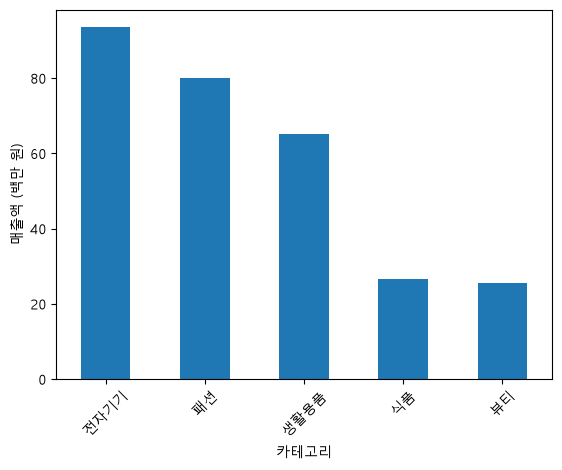

In [ ]:
# 55. 카테고리별 매출액을 막대그래프로 표현하시오.
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.rcParams['font.family']='Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

category_total = df.groupby('category')['price'].sum()
category_total_sorted = category_total.sort_values(ascending=False)
ax = (category_total_sorted / 1_000_000).plot(kind='bar', rot=45)
plt.xlabel('카테고리')
plt.ylabel('매출액 (백만 원)')
plt.show()

### 56. 지역별 매출액을 막대그래프로 표현하시오.

**답안 작성: 강은영**

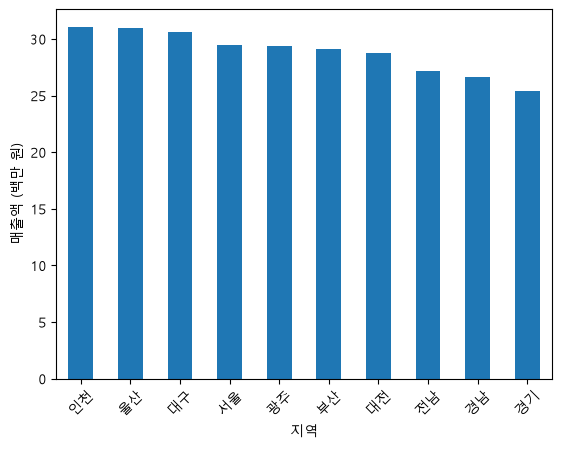

In [ ]:
# 56. 지역별 매출액을 막대그래프로 표현하시오.
region_total = df.groupby('region')['price'].sum()
region_total_sorted = region_total.sort_values(ascending=False)
ax = (region_total_sorted / 1_000_000).plot(kind='bar', rot=45)
plt.xlabel('지역')
plt.ylabel('매출액 (백만 원)')
plt.show()

### 57. 월별 매출액 추이를 선그래프로 표현하시오.

**답안 작성: 강은영**

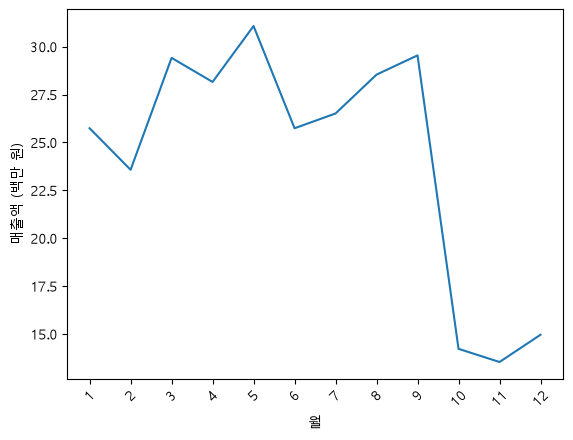

In [ ]:
# 57. 월별 매출액 추이를 선그래프로 표현하시오.
df['order_date'] = pd.to_datetime(df['order_date'])
month_total = df.groupby(df['order_date'].dt.month)['price'].sum()
ax = (month_total / 1_000_000).plot(rot=45)
plt.xticks(range(1, 13))
plt.xlabel('월')
plt.ylabel('매출액 (백만 원)')
plt.show()

### 58. 일별 매출과 7일 이동평균을 하나의 그래프에 표현하시오.

**답안 작성: 강은영**

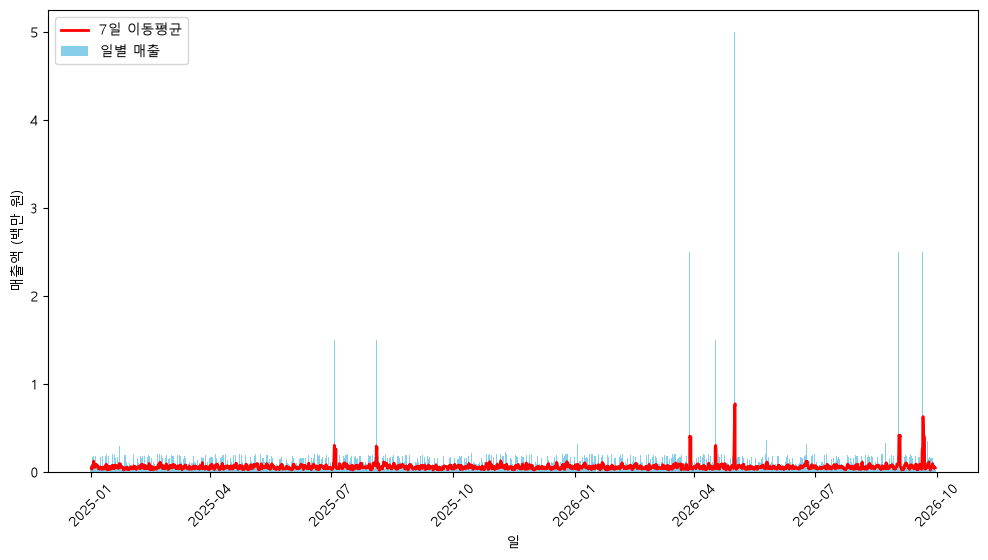

In [ ]:
# 58. 일별 매출과 7일 이동평균을 하나의 그래프에 표현하시오.
fig, ax1 = plt.subplots(figsize=(12, 6))

df['order_date'] = pd.to_datetime(df['order_date'])

# 1. 일별 매출 집계 및 백만 원 단위 변환
daily_sales = df.groupby('order_date')['price'].sum() / 1_000_000

# 2. 7일 이동평균 계산
daily_ma7 = daily_sales.rolling(window=7).mean()

# 3. 일별 매출 (막대 그래프)
ax1.bar(daily_sales.index, daily_sales.values, color='skyblue', label='일별 매출', width=0.8)

# 4. 7일 이동평균 (라인 그래프)
ax1.plot(daily_ma7.index, daily_ma7.values, color='red', linewidth=2, label='7일 이동평균')

plt.xlabel('일')
plt.ylabel('매출액 (백만 원)')
plt.legend(loc='upper left')
plt.xticks(rotation=45)
plt.show()

### 59. 시간대별 주문 건수를 그래프로 표현하시오.

**답안 작성: 강은영**

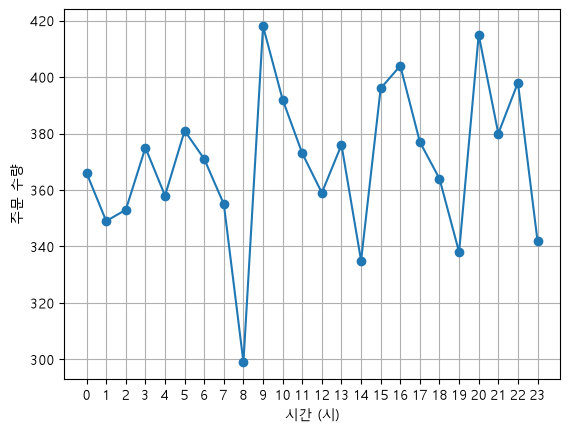

In [ ]:
# 59. 시간대별 주문 건수를 그래프로 표현하시오.
df['order_date'] = pd.to_datetime(df['order_date'])

time_total = df.groupby(df['order_date'].dt.hour)['quantity'].sum()

time_total.plot(kind='line', marker='o')

plt.xlabel('시간 (시)')
plt.ylabel('주문 수량')

plt.xticks(range(0, 24))
plt.grid(True)  
plt.show()

## 12. 종합 분석

### 60~65번 종합 분석 준비

데이터 출처: **`shopping_sales - 원본.csv`**. 노트북과 같은 작업 폴더에 두고 아래 준비 셀부터 실행합니다.

- 원본 5,080행에서 전체 컬럼이 같은 중복 80행을 제거한 **5,000주문**을 분석합니다.
- 나이는 원본 평균으로, 성별·지역·결제수단 결측치는 `미상`으로 채웁니다. 앞선 문제 지시와 같은 순서로 결측치 처리 후 중복을 제거합니다.
- 매출액은 `price × quantity × (1 - discount)`입니다. 시간대와 결제수단의 주문 건수는 고유 `order_id` 개수입니다.
- 이상치는 원본에 포함된 상태로 유지합니다. 앞선 문제에는 이상치 삭제 지시가 없습니다.
- 60~65번의 준비 코드·풀이 코드·출력은 실제 실행해 확인했습니다. 앞선 팀원 답안의 저장된 출력과는 실행 기준이 다를 수 있습니다.

In [1]:
# 60~65번은 이 셀부터 실행할 수 있습니다.
# 앞선 팀원 코드의 df 상태와 별개로 원본 CSV에서 다시 준비합니다.
from pathlib import Path
import pandas as pd

csv_path_60_65 = Path("shopping_sales - 원본.csv")
if not csv_path_60_65.is_file():
    raise FileNotFoundError(
        "노트북과 같은 작업 폴더에 'shopping_sales - 원본.csv'를 넣어 주세요. "
        "VS Code 터미널의 현재 폴더도 확인해 주세요."
    )

raw_60_65 = pd.read_csv(csv_path_60_65, encoding="utf-8-sig")
df_60_65 = raw_60_65.copy()

# 8~10번 기준: 나이는 평균값, 범주형 결측치는 '미상'으로 채웁니다.
df_60_65["age"] = df_60_65["age"].fillna(df_60_65["age"].mean())
for column in ["gender", "region", "payment"]:
    df_60_65[column] = df_60_65[column].fillna("미상")

# 12번 기준: 전체 컬럼이 같은 중복 행을 제거합니다.
df_60_65 = df_60_65.drop_duplicates().reset_index(drop=True)

# 19번 기준: 할인과 수량을 반영한 판매금액을 사용합니다.
df_60_65["sales"] = (
    df_60_65["price"] * df_60_65["quantity"] * (1 - df_60_65["discount"])
)

# 21번 기준: 10대=[10,20), 20대=[20,30), ..., 70대 이상=[70,무한).
df_60_65["age_group"] = pd.cut(
    df_60_65["age"],
    bins=[10, 20, 30, 40, 50, 60, 70, float("inf")],
    labels=["10대", "20대", "30대", "40대", "50대", "60대", "70대 이상"],
    right=False,
)
df_60_65["order_date"] = pd.to_datetime(df_60_65["order_date"])
df_60_65["hour"] = df_60_65["order_date"].dt.hour

total_sales_60_65 = df_60_65["sales"].sum()
total_orders_60_65 = df_60_65["order_id"].nunique()
print(f"원본 행: {len(raw_60_65):,} / 중복 제거: {len(raw_60_65)-len(df_60_65):,} / 분석 주문: {total_orders_60_65:,}")
print(f"전체 매출액: {total_sales_60_65:,.0f}원")
print(f"분석 기간: {df_60_65['order_date'].min()} ~ {df_60_65['order_date'].max()}")


원본 행: 5,080 / 중복 제거: 80 / 분석 주문: 5,000
전체 매출액: 474,593,680원
분석 기간: 2025-01-01 02:58:18 ~ 2026-09-29 21:14:16


### 60. 매출액이 가장 높은 카테고리를 찾고 결과를 설명하시오.

**답안 작성: 추가 풀이**

In [2]:
# 60. 매출액이 가장 높은 카테고리
category_sales_60 = df_60_65.groupby("category")["sales"].sum().sort_values(ascending=False)
category_result_60 = category_sales_60.to_frame("매출액(원)")
category_result_60["매출비중(%)"] = category_sales_60 / total_sales_60_65 * 100
print(category_result_60.to_string(formatters={
    "매출액(원)": lambda value: f"{value:,.0f}",
    "매출비중(%)": lambda value: f"{value:.2f}",
}))
top_categories_60 = category_sales_60[category_sales_60 == category_sales_60.max()]
print("\n매출 1위 카테고리:", ", ".join(top_categories_60.index))
print(f"매출액: {category_sales_60.max():,.0f}원")


              매출액(원) 매출비중(%)
category                    
전자기기     152,048,335   32.04
패션       138,538,790   29.19
생활용품     106,740,635   22.49
식품        38,799,980    8.18
뷰티        38,465,940    8.11

매출 1위 카테고리: 전자기기
매출액: 152,048,335원


**결과 설명:** 매출액이 가장 높은 카테고리는 **전자기기**입니다. 매출액은 **152,048,335원**, 전체 매출의 **32.04%**입니다. 2위 패션(138,538,790원)보다 높습니다. 수량과 할인율을 반영한 `sales` 합계를 기준으로 비교했습니다.

매출액이 가장 높은 카테고리는 **전자기기**입니다. 전자기기의 매출액은 **152,048,335원**으로 전체 매출의 **32.04%**를 차지했습니다. 2위 패션과의 매출 격차는 **13,509,545원**(비중 차이 약 2.85%p)입니다. 두 카테고리를 합하면 전체 매출의 약 **61.23%**로, 매출이 이 두 카테고리에 집중되어 있습니다. 다만 매출 합계만으로는 이 차이가 판매량, 단가, 할인율 중 무엇에서 비롯됐는지 판단하기 어렵습니다.

### 61. 매출액이 가장 높은 지역을 찾고 결과를 설명하시오.

**답안 작성: 추가 풀이**

In [3]:
# 61. 매출액이 가장 높은 지역
region_sales_61 = df_60_65.groupby("region")["sales"].sum().sort_values(ascending=False)
region_result_61 = region_sales_61.to_frame("매출액(원)")
region_result_61["매출비중(%)"] = region_sales_61 / total_sales_60_65 * 100
print(region_result_61.to_string(formatters={
    "매출액(원)": lambda value: f"{value:,.0f}",
    "매출비중(%)": lambda value: f"{value:.2f}",
}))
top_regions_61 = region_sales_61[region_sales_61 == region_sales_61.max()]
print("\n매출 1위 지역:", ", ".join(top_regions_61.index))
print(f"매출액: {region_sales_61.max():,.0f}원")


           매출액(원) 매출비중(%)
region                   
울산     56,023,660   11.80
인천     54,426,825   11.47
서울     50,901,450   10.73
대구     48,380,020   10.19
전남     45,530,220    9.59
부산     44,957,415    9.47
대전     44,079,405    9.29
경기     43,814,965    9.23
경남     41,300,970    8.70
광주     41,044,280    8.65
미상      4,134,470    0.87

매출 1위 지역: 울산
매출액: 56,023,660원


**결과 설명:** 매출액이 가장 높은 지역은 **울산**입니다. 매출액은 **56,023,660원**, 전체 매출의 **11.80%**입니다. 2위 인천은 54,426,825원입니다. 이 결과는 제공된 데이터의 전체 기간 매출 합계이며 지역별 인구나 광고비를 보정한 값은 아닙니다.

### 62. 가장 많이 이용된 결제수단을 찾으시오.

**답안 작성: 추가 풀이**

In [4]:
# 62. 가장 많이 이용된 결제수단: 주문 건수를 셉니다.
payment_orders_62 = df_60_65.groupby("payment")["order_id"].nunique().sort_values(ascending=False)
payment_result_62 = payment_orders_62.to_frame("주문건수")
payment_result_62["주문비중(%)"] = payment_orders_62 / total_orders_60_65 * 100
print(payment_result_62.to_string(formatters={"주문비중(%)": lambda value: f"{value:.2f}"}))
top_payments_62 = payment_orders_62[payment_orders_62 == payment_orders_62.max()]
print("\n가장 많이 이용된 결제수단:", ", ".join(top_payments_62.index))
print(f"주문 건수: {payment_orders_62.max():,}건")


         주문건수 주문비중(%)
payment              
계좌이체     1026   20.52
체크카드      997   19.94
간편결제      991   19.82
신용카드      976   19.52
무통장입금     975   19.50
미상         35    0.70

가장 많이 이용된 결제수단: 계좌이체
주문 건수: 1,026건


**결과:** 가장 많이 이용된 결제수단은 **계좌이체**입니다. **1,026건**, 전체 5,000건 중 **20.52%**입니다. 체크카드 997건, 간편결제 991건이 뒤를 잇습니다. 한 주문의 구매 수량과 구분하여 고유 주문번호를 셌습니다.

### 63. 가장 매출이 높은 연령대를 찾으시오.

**답안 작성: 추가 풀이**

In [5]:
# 63. 매출액이 가장 높은 연령대
age_sales_63 = df_60_65.groupby("age_group", observed=True)["sales"].sum().sort_values(ascending=False)
age_result_63 = age_sales_63.to_frame("매출액(원)")
age_result_63["매출비중(%)"] = age_sales_63 / total_sales_60_65 * 100
print(age_result_63.to_string(formatters={
    "매출액(원)": lambda value: f"{value:,.0f}",
    "매출비중(%)": lambda value: f"{value:.2f}",
}))
top_ages_63 = age_sales_63[age_sales_63 == age_sales_63.max()]
print("\n매출 1위 연령대:", ", ".join(str(value) for value in top_ages_63.index))
print(f"매출액: {age_sales_63.max():,.0f}원")


               매출액(원) 매출비중(%)
age_group                    
20대       107,808,795   22.72
30대        92,087,000   19.40
50대        88,911,570   18.73
60대        87,440,245   18.42
40대        80,742,825   17.01
10대        17,292,125    3.64
70대 이상        311,120    0.07

매출 1위 연령대: 20대
매출액: 107,808,795원


**결과:** 매출액이 가장 높은 연령대는 **20대**입니다. 매출액은 **107,808,795원**, 전체 매출의 **22.72%**입니다. 2위 30대는 92,087,000원입니다. 결측 나이는 원본 평균으로 채운 뒤, 20세 이상 30세 미만을 20대로 분류했습니다.

### 64. 가장 주문이 많은 시간대를 찾으시오.

**답안 작성: 추가 풀이**

In [6]:
# 64. 주문이 가장 많은 시간대: 수량 합계가 아닌 고유 주문 건수
hour_orders_64 = df_60_65.groupby("hour")["order_id"].nunique().sort_index()
hour_result_64 = hour_orders_64.to_frame("주문건수")
hour_result_64["주문비중(%)"] = hour_orders_64 / total_orders_60_65 * 100
print(hour_result_64.to_string(formatters={"주문비중(%)": lambda value: f"{value:.2f}"}))
top_hours_64 = hour_orders_64[hour_orders_64 == hour_orders_64.max()]
print("\n주문이 가장 많은 시간대:", ", ".join(f"{hour:02d}:00~{hour:02d}:59" for hour in top_hours_64.index))
print(f"주문 건수: {hour_orders_64.max():,}건")


      주문건수 주문비중(%)
hour              
0      194    3.88
1      199    3.98
2      199    3.98
3      211    4.22
4      185    3.70
5      213    4.26
6      223    4.46
7      220    4.40
8      180    3.60
9      205    4.10
10     199    3.98
11     226    4.52
12     196    3.92
13     201    4.02
14     198    3.96
15     228    4.56
16     219    4.38
17     227    4.54
18     213    4.26
19     189    3.78
20     231    4.62
21     217    4.34
22     218    4.36
23     209    4.18

주문이 가장 많은 시간대: 20:00~20:59
주문 건수: 231건


**결과:** 주문이 가장 많은 시간대는 **20:00~20:59**입니다. **231건**, 전체 주문의 **4.62%**입니다. 15시 228건, 17시 227건이 뒤를 잇습니다. 전체 분석 기간의 같은 시간대를 합산한 결과입니다.

### 65. 분석 결과를 바탕으로 쇼핑몰 담당자에게 제안할 수 있는 마케팅 전략 3가지를 작성하시오.

각 전략은 반드시 다음 형식으로 작성하시오.

- 분석 결과
- 데이터 근거
- 제안 전략

**답안 작성: 추가 풀이**

In [7]:
# 65. 마케팅 전략에 사용할 추가 근거
# 연령대 및 지역별로 실제 많이 팔린 카테고리를 함께 확인합니다.
age_category_sales_65 = df_60_65.groupby(["age_group", "category"], observed=True)["sales"].sum()
fashion_20s_sales_65 = age_category_sales_65.loc[("20대", "패션")]
ulsan_category_sales_65 = df_60_65.loc[df_60_65["region"] == "울산"].groupby("category")["sales"].sum().sort_values(ascending=False)
print(f"20대 패션 매출: {fashion_20s_sales_65:,.0f}원")
print("\n울산 카테고리별 매출")
print(ulsan_category_sales_65.to_string(float_format=lambda value: f"{value:,.0f}"))
print(f"\n20시 주문 비중: {hour_orders_64.loc[20] / total_orders_60_65 * 100:.2f}%")
print(f"계좌이체 주문 비중: {payment_orders_62.loc['계좌이체'] / total_orders_60_65 * 100:.2f}%")


20대 패션 매출: 37,010,335원

울산 카테고리별 매출
category
패션     26,901,520
전자기기   12,412,245
생활용품    9,904,840
식품      3,460,795
뷰티      3,344,260

20시 주문 비중: 4.62%
계좌이체 주문 비중: 20.52%


#### 전략 1. 주력 상품 노출과 20대 맞춤 추천

- **분석 결과:** 전체 매출은 전자기기가 가장 높고, 연령대별 매출은 20대가 가장 높습니다. 20대 안에서는 패션 매출이 가장 높습니다.
- **데이터 근거:** 전자기기 매출 152,048,335원(32.04%), 20대 매출 107,808,795원(22.72%), 20대 패션 매출 37,010,335원입니다.
- **제안 전략:** 전체 상품 기획에서는 전자기기 대표 상품과 관련 상품 묶음을 노출하고, 20대 고객에게는 패션 상품 추천과 코디 묶음을 보여줍니다. 추천 전후의 주문 전환율과 객단가를 비교해 확대 여부를 결정합니다.

#### 전략 2. 울산 고객 대상 패션 캠페인

- **분석 결과:** 울산이 지역별 매출 1위이며, 울산에서는 패션 카테고리의 매출이 가장 높습니다.
- **데이터 근거:** 울산 매출 56,023,660원(11.80%), 울산 패션 매출 26,901,520원으로 울산 매출의 48.02%입니다.
- **제안 전략:** 울산 고객에게 패션 신상품과 재구매 추천을 우선 안내하고, 지역 대상 배송 쿠폰을 소규모로 시험합니다. 쿠폰 비용을 포함한 매출과 재구매율을 확인한 뒤 운영 범위를 조정합니다.

#### 전략 3. 20시 프로모션과 결제 안내 개선

- **분석 결과:** 20시의 주문 건수가 가장 많고, 결제수단 중 계좌이체 이용 건수가 가장 많습니다.
- **데이터 근거:** 20:00~20:59 주문 231건(4.62%), 계좌이체 1,026건(20.52%)입니다. 계좌이체와 체크카드의 차이는 29건입니다.
- **제안 전략:** 20시 시작 프로모션을 다른 시간대와 비교 시험하고, 계좌이체의 입금 정보·확인 절차를 명확하게 안내합니다. 다른 결제수단도 쉽게 선택할 수 있게 유지하며 시간대별 전환율과 결제 이탈률로 효과를 확인합니다.

각 제안은 관측된 판매 구성에 근거한 시험 아이디어입니다. 이 데이터만으로 광고 효과나 쿠폰의 매출 증가율이 입증된 것은 아닙니다.


## 참고: 중복 제출 답안과 원본 준비 코드

기본 답안은 파일명에 명시된 담당 단원을 기준으로 배치했습니다. 다른 담당자가 작성한 1~7번 중복 풀이와 개별 파일의 데이터 불러오기 코드는 아래에 보존했습니다. 이 부분은 추가 참고 자료입니다.

### 이준원 - 참고 코드

출처: `데이터분석프로젝트_2번_7번_답안_이준원.ipynb` / 원본 코드 셀 위치: 4번째 셀(1부터 계산).

In [ ]:
# 2. 결측치 처리

# 데이터 불러오기
import pandas as pd

df = pd.read_csv("shopping_sales.csv", encoding="utf-8-sig")



### 이재현 - 참고 코드

출처: `이재현_4번_9번_데이터분석프로젝트.ipynb` / 원본 코드 셀 위치: 4번째 셀(1부터 계산).

In [ ]:
#1
df = pd.read_csv('data/shopping_sales.csv')

#2
df.head(5)

,order_id,order_date,customer_id,gender,age,region,category,product,quantity,price,discount,payment
0,ORD002588,2025-05-30 03:04:29,C00281,여,33.0,인천,식품,생수24개,1,11100,0.15,간편결제
1,ORD000526,2025-12-01 06:15:22,C00333,남,30.0,부산,생활용품,수납함,5,26400,0.00,체크카드
2,ORD001244,2025-11-09 10:57:44,C00786,남,19.0,부산,뷰티,수분크림,2,31300,0.10,NaN
3,ORD002049,2026-01-18 17:59:52,C01015,여,44.0,경기,패션,청바지,1,67000,0.15,계좌이체
4,ORD000730,2025-07-15 07:43:08,C00397,여,43.0,울산,생활용품,전기포트,2,49900,0.00,계좌이체


### 이재현 - 참고 코드

출처: `이재현_4번_9번_데이터분석프로젝트.ipynb` / 원본 코드 셀 위치: 5번째 셀(1부터 계산).

In [ ]:
#3
df.shape

(5080, 12)

### 이재현 - 참고 코드

출처: `이재현_4번_9번_데이터분석프로젝트.ipynb` / 원본 코드 셀 위치: 6번째 셀(1부터 계산).

In [ ]:
#4
df.dtypes

order_id           str
order_date         str
customer_id        str
gender             str
age            float64
region             str
category           str
product            str
quantity         int64
price            int64
discount       float64
payment            str
dtype: object

### 이재현 - 참고 코드

출처: `이재현_4번_9번_데이터분석프로젝트.ipynb` / 원본 코드 셀 위치: 7번째 셀(1부터 계산).

In [ ]:
#5
df.describe()

,age,quantity,price,discount
count,5039.000000,5080.000000,5.080000e+03,5080.000000
mean,43.475293,1.746850,5.728638e+04,0.085728
std,15.450369,1.628795,1.091799e+05,0.086759
min,18.000000,1.000000,1.110000e+04,0.000000
25%,30.000000,1.000000,2.310000e+04,0.000000
50%,43.000000,1.000000,3.320000e+04,0.100000
75%,57.000000,2.000000,7.350000e+04,0.100000
max,135.000000,50.000000,5.000000e+06,0.300000


### 이재현 - 참고 코드

출처: `이재현_4번_9번_데이터분석프로젝트.ipynb` / 원본 코드 셀 위치: 9번째 셀(1부터 계산).

In [ ]:
#6

df.isna().sum()

order_id        0
order_date      0
customer_id     0
gender         30
age            41
region         46
category        0
product         0
quantity        0
price           0
discount        0
payment        37
dtype: int64

### 이재현 - 참고 코드

출처: `이재현_4번_9번_데이터분석프로젝트.ipynb` / 원본 코드 셀 위치: 10번째 셀(1부터 계산).

In [ ]:
#7

df.isnull().sum()[df.isnull().sum() > 0]

gender     30
age        41
region     46
payment    37
dtype: int64

### 윤지석 - 참고 코드

출처: `데이터분석프로젝트(윤지석).ipynb` / 원본 코드 셀 위치: 2번째 셀(1부터 계산).

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
plt.rcParams['font.family']='Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv("data/shopping_sales.csv")

### 강은영 - 참고 코드

출처: `데이터분석프로젝트_2조강은영.ipynb` / 원본 코드 셀 위치: 2번째 셀(1부터 계산).

In [ ]:
import pandas as pd

df = pd.read_csv('shopping_sales.csv')
df

,order_id,order_date,customer_id,gender,age,region,category,product,quantity,price,discount,payment
0,ORD002588,2025-05-30 03:04:29,C00281,여,33.0,인천,식품,생수24개,1,11100,0.15,간편결제
1,ORD000526,2025-12-01 06:15:22,C00333,남,30.0,부산,생활용품,수납함,5,26400,0.00,체크카드
2,ORD001244,2025-11-09 10:57:44,C00786,남,19.0,부산,뷰티,수분크림,2,31300,0.10,NaN
3,ORD002049,2026-01-18 17:59:52,C01015,여,44.0,경기,패션,청바지,1,67000,0.15,계좌이체
4,ORD000730,2025-07-15 07:43:08,C00397,여,43.0,울산,생활용품,전기포트,2,49900,0.00,계좌이체
...,...,...,...,...,...,...,...,...,...,...,...,...
5075,ORD002341,2025-11-26 03:33:33,C01153,NaN,32.0,대전,패션,백팩,1,74600,0.05,계좌이체
5076,ORD003467,2025-07-12 08:34:35,C01228,여,38.0,경남,전자기기,스마트워치,1,153200,0.00,계좌이체
5077,ORD004566,2025-01-22 12:16:30,C01123,여,53.0,광주,전자기기,스마트워치,1,146800,0.10,신용카드
5078,ORD002555,2026-07-02 19:15:16,C00397,남,31.0,경남,패션,셔츠,1,48400,0.30,체크카드


## 취합 메모

- **60~65번 추가 완료:** 제공된 원본 CSV로 계산 코드·결과 설명·마케팅 전략을 작성하고 실제 실행한 출력을 포함했습니다.
- **중복 답안:** 이재현 제출본의 1~7번 풀이를 참고 부분에 보존했습니다. 기본 답안은 박주형(1~5번), 이준원(6~7번)입니다.
- **다중 문제 셀:** 이준원 제출본의 6~10번과 26~36번을 문제별 코드 셀로 나눴습니다. 저장된 출력도 번호에 맞춰 나눠 보존했습니다.
- **1~59번 저장된 출력:** 각 팀원의 개별 파일에서 실행된 결과입니다. 파일별 결측치·중복 처리 상태가 달라, 이 취합본을 순서대로 실행하면 기존 출력과 다를 수 있습니다.
- **18번:** `u_limit`, `l_limit`를 출력하지만 제출된 코드 안에 해당 변수 정의가 없습니다. 원본 코드를 유지했습니다.
- **23번:** 조건에 판매금액 `sales` 대신 `price`를 사용하고 있어 문제 조건과 비교 검토가 필요합니다.
- **48~58번:** 일부 매출 계산이 `sales` 대신 `price` 기준이며, 날짜 집계 단위와 7일 이동평균도 문제 조건과 비교 검토가 필요합니다.
- **59번:** 주문 건수 대신 `quantity` 합계를 사용하고 있어 집계 기준 검토가 필요합니다.
- **통합 실행:** 47번에서 `order_date`를 인덱스로 옮긴 뒤 57~59번은 `order_date` 컬럼을 참조합니다. 실행용으로 정비할 때 컬럼/인덱스 연결을 조정해야 합니다.
- **데이터 경로:** 1번 기본 답안은 GitHub CSV 주소를 사용합니다. 참고 코드에는 `shopping_sales.csv`와 `data/shopping_sales.csv` 경로가 섞여 있습니다.

1~59번은 제공된 문제와 팀원 답안의 배치·취합본이며 원본 코드를 유지했습니다. 60~65번은 원본 CSV를 바탕으로 추가한 실행 확인 풀이입니다.
